*(cell 1)*

# 23 -- $\Delta E$ quadrant analysis: what $\mathbb{D}$ sees that $\mathbb{R}$ cannot

## Background

The hyperbolic energy difference decomposes as

$$\Delta E = \Delta_1 e_+ + \Delta_2 e_-, \qquad J = e_+ - e_- = k$$

Four mutually exclusive cases follow from the signs of $\Delta_1$ and $\Delta_2$:

| Case | Condition | Meaning |
|---|---|---|
| 1 | $\Delta E > 0$ ($\Delta_1>0,\ \Delta_2>0$) | nothing -- both channels agree the true rating is more probable than the reconstruction |
| 2 | $\Delta E < 0$ ($\Delta_1<0,\ \Delta_2<0$) | change both -- both channels are off |
| 3 | $J\Delta E > 0$ ($\Delta_1>0,\ \Delta_2<0$) | change $\Delta_2$ -- only the $e_-$ channel is off |
| 4 | $J\Delta E < 0$ ($\Delta_1<0,\ \Delta_2>0$) | change $\Delta_1$ -- only the $e_+$ channel is off |

A real-valued RBM only ever sees the scalar sign of $\Delta E = \Delta_1+\Delta_2$ -- it can tell case {1,2} (agree) from... nothing else, because $\Delta_1$ and $\Delta_2$ are summed into one number before the sign is taken. Cases 3 and 4 are invisible to $\mathbb{R}$: a positive $\Delta_1$ can cancel a negative $\Delta_2$ (or vice versa) and still land on either side of zero. The $\mathbb{D}$-valued view keeps $\Delta_1$ and $\Delta_2$ as two separate numbers, so it can resolve *which* channel is responsible for an error -- a diagnostic resolution the real-valued model cannot express.

Part A demonstrates this on a single user (3268, consistent with notebooks 17/18/19/21). Part B repeats it, vectorized, across the full 1,032,307-pair test set for all 5,000 users, and checks whether the channel-level diagnosis explains known patterns (e.g. strict raters).

*(cell 2)*

## Part 0 -- Setup

In [1]:
# cell 3
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

root = Path.cwd().resolve()
if root.name == "notebooks":
    root = root.parent
proc = root / "data" / "processed"
out_dir = root / "outputs"
out_dir.mkdir(parents=True, exist_ok=True)

K = 10
RATING_LEVELS = np.array([0.5, 1.0, 1.5, 2.0, 2.5, 3.0, 3.5, 4.0, 4.5, 5.0])
DEMO_USER_ID = 3268


def sigmoid(x):
    return 1.0 / (1.0 + np.exp(-np.clip(x, -60.0, 60.0)))


def softmax(x, axis=-1):
    x = x - x.max(axis=axis, keepdims=True)
    e = np.exp(x)
    return e / e.sum(axis=axis, keepdims=True)


# same loading convention as notebook 14b's Part 0
W1 = np.load(proc / "rbmB1_weights_5k.npy")
bh1 = np.load(proc / "rbmB1_bias_hidden_5k.npy")
W2 = np.load(proc / "rbmB2_weights_5k.npy")
bh2 = np.load(proc / "rbmB2_bias_hidden_5k.npy")
channelB1 = np.load(proc / "channelB1_softmax.npy", mmap_mode="r")
channelB2 = np.load(proc / "channelB2_personality.npy", mmap_mode="r")
mask = np.load(proc / "mask.npy", mmap_mode="r")
cohort_user_ids = np.load(proc / "cohort_user_ids.npy").astype(int)
movie_vocab = np.load(proc / "movie_vocab.npy").astype(int)
user_means = np.load(proc / "user_means.npy").astype(np.float64)
test_labels = pd.read_csv(proc / "test_labels.csv")
mu_global = float(np.load(proc / "mu_global.npy"))

n_users, n_movies, _ = channelB1.shape
n_hidden = bh1.shape[0]
assert W1.shape == (n_movies * K, n_hidden)
assert W2.shape == (n_movies, n_hidden)

user_to_row = {int(uid): i for i, uid in enumerate(cohort_user_ids)}
movie_to_col = {int(mid): j for j, mid in enumerate(movie_vocab)}

W1_r = W1.reshape(n_movies, K, n_hidden)

print(f"n_users={n_users}  n_movies={n_movies}  n_hidden={n_hidden}")
print(f"mu_global={mu_global:.4f}")
print(f"test_labels: {len(test_labels)} pairs, {test_labels['userId'].nunique()} users")

n_users=5000  n_movies=13129  n_hidden=128
mu_global=3.3281
test_labels: 1032307 pairs, 5000 users


In [2]:
# cell 4
# hidden activations for all 5,000 users -- same formula as notebook 14b / notebook 21
X1 = np.asarray(channelB1, dtype=np.float32).reshape(n_users, -1)
X2 = np.asarray(channelB2, dtype=np.float32).reshape(n_users, -1)

H1 = sigmoid(X1 @ W1 + bh1)
H2 = sigmoid(X2 @ W2 + bh2)

print(f"H1: {H1.shape}  H2: {H2.shape}")

H1: (5000, 128)  H2: (5000, 128)


*(cell 5)*

## Part A -- single user demo (user 3268)

Energy terms, per test movie $j$, no visible bias (same convention as notebook 21):

$$J_{1}(j,k) = \sum_l W^{(1)}_{(j,k),l}\, h^{(1)}_l \qquad P(k\mid h^{(1)}) = \mathrm{softmax}_k\big(J_1(j,\cdot)\big)$$

$$e_{1,\text{true}}(j) = -J_1(j,k^*) \qquad e_{1,\text{pred}}(j) = -\sum_k P(k\mid h^{(1)})\,J_1(j,k) \qquad \Delta_1(j) = e_{1,\text{pred}}(j) - e_{1,\text{true}}(j)$$

$$J_{2}(j) = \sum_l W^{(2)}_{j,l}\, h^{(2)}_l \qquad v_{\text{recon},2}(j) = \sigma\big(J_2(j)\big)$$

$$e_{2,\text{true}}(j) = -(\mu_{\text{user}}-\mu_{\text{global}})\,J_2(j) \qquad e_{2,\text{pred}}(j) = -v_{\text{recon},2}(j)\,J_2(j) \qquad \Delta_2(j) = e_{2,\text{pred}}(j) - e_{2,\text{true}}(j)$$

A positive $\Delta$ means the reconstruction's energy is higher than the true rating's energy -- i.e. the model assigns the true rating higher probability (lower energy), so that channel got this movie right. A negative $\Delta$ means the true rating's energy is higher than the reconstruction's -- the model favors something other than the true rating, so that channel got it wrong.

**Known issue, verified separately:** user 3268's e- (channel B2 / personality) hidden layer is 100% saturated (sigmoid pinned to 0 or 1 for all 128 units) -- channel B2's personality scalar is broadcast unnormalized across every rated movie, and this user's magnitude blows the pre-activation past sigmoid's effective range. Delta2 below is floating-point noise, not real signal. Part A is kept as a worked mechanical example of the computation steps, but its Delta2/quadrant numbers should not be read as genuine e- behavior -- see Part B's filtered results for numbers that are actually trustworthy.

In [3]:
# cell 6
demo_row = user_to_row[DEMO_USER_ID]
h1_demo = H1[demo_row]
h2_demo = H2[demo_row]
user_mean_demo = user_means[demo_row]
personality_true_demo = user_mean_demo - mu_global

demo_test = test_labels[test_labels["userId"] == DEMO_USER_ID].reset_index(drop=True)
demo_test["movie_col"] = demo_test["movieId"].map(movie_to_col)
demo_test = demo_test.dropna(subset=["movie_col"]).copy()
demo_test["movie_col"] = demo_test["movie_col"].astype(int)
demo_test["k_star"] = np.round(demo_test["rating"].values * 2).astype(int) - 1

movie_cols = demo_test["movie_col"].values
k_stars = demo_test["k_star"].values

J1_demo = W1_r[movie_cols] @ h1_demo                      # (n_test, K)
P1_demo = softmax(J1_demo, axis=1)
e1_true = -J1_demo[np.arange(len(movie_cols)), k_stars]
e1_pred = -(P1_demo * J1_demo).sum(axis=1)
Delta1_demo = e1_pred - e1_true

J2_demo = W2[movie_cols] @ h2_demo                          # (n_test,)
v_recon2_demo = sigmoid(J2_demo)
e2_true = -personality_true_demo * J2_demo
e2_pred = -v_recon2_demo * J2_demo
Delta2_demo = e2_pred - e2_true

sig1_demo = sigmoid(J1_demo)
denom_demo = sig1_demo.sum(axis=1)
denom_demo = np.where(denom_demo > 0, denom_demo, 1.0)
r1_demo = (sig1_demo * RATING_LEVELS).sum(axis=1) / denom_demo
r_joint_demo = np.clip(r1_demo + v_recon2_demo, 0.5, 5.0)

true_rating_demo = demo_test["rating"].values
err_real_demo = np.abs(r1_demo - true_rating_demo)
err_hyp_demo = np.abs(r_joint_demo - true_rating_demo)


def classify_quadrant(d1, d2):
    q = np.full(len(d1), "", dtype="<U20")
    q[(d1 > 0) & (d2 > 0)] = "Q1 nothing"
    q[(d1 < 0) & (d2 < 0)] = "Q2 change both"
    q[(d1 > 0) & (d2 < 0)] = "Q3 change e-"
    q[(d1 < 0) & (d2 > 0)] = "Q4 change e+"
    return q


quadrant_demo = classify_quadrant(Delta1_demo, Delta2_demo)

demo_test["Delta1"] = Delta1_demo
demo_test["Delta2"] = Delta2_demo
demo_test["quadrant"] = quadrant_demo
demo_test["r1_pred"] = r1_demo
demo_test["r_joint_pred"] = r_joint_demo
demo_test["err_real"] = err_real_demo
demo_test["err_hyp"] = err_hyp_demo

print(f"user {DEMO_USER_ID}: {len(demo_test)} test movies, user_mean={user_mean_demo:.4f}, personality_true={personality_true_demo:+.4f}")

user 3268: 175 test movies, user_mean=3.6466, personality_true=+0.3185


In [4]:
# cell 7
cols = ["movieId", "rating", "Delta1", "Delta2", "quadrant", "r1_pred", "r_joint_pred", "err_real", "err_hyp"]
display(demo_test[cols].head(20).round(4))

,movieId,rating,Delta1,Delta2,quadrant,r1_pred,r_joint_pred,err_real,err_hyp
0,72998,4.5,-0.3603,0.0,Q4 change e+,3.6460,4.1460,0.8540,0.3540
1,70697,2.5,0.2164,0.0,Q1 nothing,2.7165,3.2165,0.2165,0.7165
2,70282,2.0,-0.1102,0.0,Q4 change e+,2.7696,3.2696,0.7696,1.2696
3,72011,4.0,0.6191,0.0,Q1 nothing,3.5160,4.0160,0.4840,0.0160
4,69757,4.0,0.6290,0.0,Q1 nothing,3.5151,4.0151,0.4849,0.0151
5,68194,3.5,0.1730,0.0,Q1 nothing,2.9784,3.4784,0.5216,0.0216
6,69278,3.0,0.3911,0.0,Q1 nothing,2.7269,3.2269,0.2731,0.2269
7,77561,4.5,-2.1705,0.0,Q4 change e+,3.2236,3.7236,1.2764,0.7764
8,73017,5.0,-3.3654,0.0,Q4 change e+,3.4695,3.9695,1.5305,1.0305
9,74450,3.5,0.1156,0.0,Q1 nothing,2.7746,3.2746,0.7254,0.2254


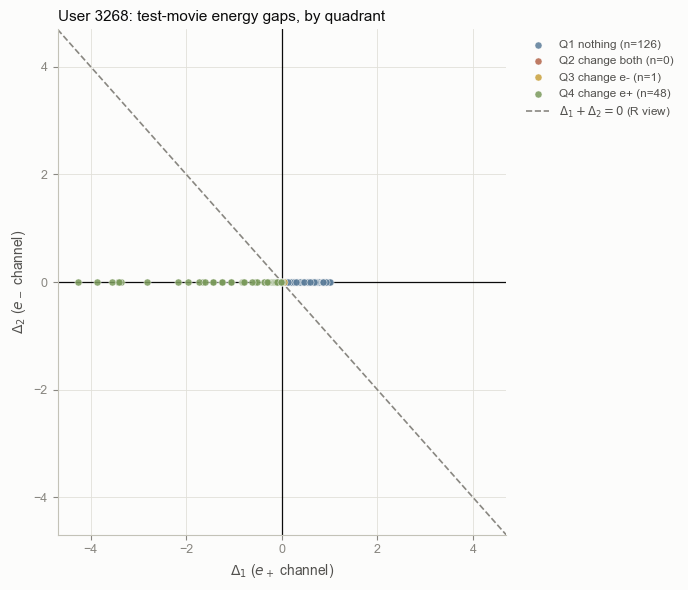

In [5]:
# cell 8
INK_PRIMARY, INK_SECONDARY, INK_MUTED = "#0b0b0b", "#52514e", "#898781"
GRID, BASELINE, SURFACE = "#e1e0d9", "#c3c2b7", "#fcfcfb"
plt.rcParams["font.family"] = ["Arial", "Helvetica", "DejaVu Sans"]

QUADRANT_COLORS = {
    "Q1 nothing": "#5b7c99",
    "Q2 change both": "#b4654a",
    "Q3 change e-": "#c9a13b",
    "Q4 change e+": "#7a9a5b",
}

fig, ax = plt.subplots(figsize=(7, 6), facecolor=SURFACE)
ax.set_facecolor(SURFACE)
for q, color in QUADRANT_COLORS.items():
    sub = demo_test[demo_test["quadrant"] == q]
    ax.scatter(sub["Delta1"], sub["Delta2"], color=color, s=26, alpha=0.85, label=f"{q} (n={len(sub)})", zorder=3, edgecolors=SURFACE, linewidths=0.4)

lim = max(np.abs(demo_test["Delta1"]).max(), np.abs(demo_test["Delta2"]).max()) * 1.1
ax.plot([-lim, lim], [lim, -lim], color=INK_MUTED, linewidth=1.2, linestyle="--", zorder=2, label=r"$\Delta_1+\Delta_2=0$ (R view)")
ax.axhline(0, color=INK_PRIMARY, linewidth=0.9, zorder=2)
ax.axvline(0, color=INK_PRIMARY, linewidth=0.9, zorder=2)
ax.set_xlim(-lim, lim)
ax.set_ylim(-lim, lim)
ax.set_xlabel(r"$\Delta_1$ ($e_+$ channel)", color=INK_SECONDARY, fontsize=10)
ax.set_ylabel(r"$\Delta_2$ ($e_-$ channel)", color=INK_SECONDARY, fontsize=10)
ax.set_title(f"User {DEMO_USER_ID}: test-movie energy gaps, by quadrant", color=INK_PRIMARY, fontsize=11, loc="left")
ax.legend(loc="upper left", bbox_to_anchor=(1.02, 1.0), frameon=False, fontsize=8.5, labelcolor=INK_SECONDARY)
for s in ("top", "right"):
    ax.spines[s].set_visible(False)
for s in ("left", "bottom"):
    ax.spines[s].set_color(BASELINE)
ax.tick_params(colors=INK_MUTED, labelsize=9)
ax.grid(color=GRID, linewidth=0.6, zorder=0)
plt.tight_layout()
plt.savefig(out_dir / f"user{DEMO_USER_ID}_deltaE_quadrant_scatter.png", dpi=150, facecolor=SURFACE, bbox_inches="tight")
plt.show()

In [6]:
# cell 9
print(f"user {DEMO_USER_ID}: quadrant breakdown ({len(demo_test)} test movies)\n")
for q in ["Q1 nothing", "Q2 change both", "Q3 change e-", "Q4 change e+"]:
    sub = demo_test[demo_test["quadrant"] == q]
    if len(sub) == 0:
        print(f"  {q:16s} n=0")
        continue
    print(f"  {q:16s} n={len(sub):3d}  mean|err_real|={sub['err_real'].mean():.4f}  mean|err_hyp|={sub['err_hyp'].mean():.4f}")

user 3268: quadrant breakdown (175 test movies)

  Q1 nothing       n=126  mean|err_real|=0.5919  mean|err_hyp|=0.2805
  Q2 change both   n=0
  Q3 change e-     n=  1  mean|err_real|=0.7746  mean|err_hyp|=0.2746
  Q4 change e+     n= 48  mean|err_real|=0.7168  mean|err_hyp|=0.5471


*(cell 10)*

## Part B -- full 5,000-user aggregate

Same $\Delta_1$/$\Delta_2$ computation, vectorized over all 1,032,307 test pairs, batched by movie (same batching strategy as notebook 14b's `predict_r1_batch`): for each movie, gather every user who rated it in the test set and do one batched matmul against that movie's weight slice, rather than looping per pair.

*(cell 11)*

##### Saturation filter, applied before any Part B aggregate

Verified fact about this trained model (not an assumption): channel B2's personality scalar is broadcast, unnormalized, across every movie a user rated, so `I2 = v2 @ W2 + bh2` saturates sigmoid to exactly 0 or exactly 1 for most users' hidden layers (system-wide, ~84% of H2 entries are pinned). When that happens Delta2 is floating-point noise, not signal, and would silently contaminate the quadrant/RMSE numbers below. Restrict everything in Part B to users where H2 is not saturated -- a data-computed filter (fewer than 10% of a user's 128 h2 units stuck at the sigmoid extremes), not a chosen threshold about what a "good" user looks like.

In [7]:
# cell 12
H2_saturated_frac = ((H2 <= 1e-6) | (H2 >= 1 - 1e-6)).mean(axis=1)
usable_user_rows = set(np.where(H2_saturated_frac < 0.1)[0])
print(f"{len(usable_user_rows)} / {n_users} users have a non-saturated e- hidden layer (< 10% of units stuck at 0/1)")
print(f"user {DEMO_USER_ID} (Part A's demo user) usable: {demo_row in usable_user_rows}")

761 / 5000 users have a non-saturated e- hidden layer (< 10% of units stuck at 0/1)
user 3268 (Part A's demo user) usable: False


In [8]:
# cell 13
tl = test_labels.copy()
tl["user_row"] = tl["userId"].map(user_to_row)
tl["movie_col"] = tl["movieId"].map(movie_to_col)
tl = tl.dropna(subset=["user_row", "movie_col"]).copy()
tl["user_row"] = tl["user_row"].astype(int)
tl["movie_col"] = tl["movie_col"].astype(int)
tl["k_star"] = np.round(tl["rating"].values * 2).astype(int) - 1

n_test = len(tl)
Delta1_all = np.empty(n_test, dtype=np.float64)
Delta2_all = np.empty(n_test, dtype=np.float64)
r1_all = np.empty(n_test, dtype=np.float64)
r_joint_all = np.empty(n_test, dtype=np.float64)
v_recon2_all = np.empty(n_test, dtype=np.float64)

tl_reset = tl.reset_index(drop=True)
for movie_col, g in tl_reset.groupby("movie_col"):
    idx = g.index.values
    urows = g["user_row"].values
    kstars = g["k_star"].values

    h1_batch = H1[urows]
    h2_batch = H2[urows]

    W_slice1 = W1_r[movie_col]                        # (K, n_hidden)
    J1 = h1_batch @ W_slice1.T                          # (b, K)
    P1 = softmax(J1, axis=1)
    e1_true = -J1[np.arange(len(idx)), kstars]
    e1_pred = -(P1 * J1).sum(axis=1)
    Delta1_all[idx] = e1_pred - e1_true

    W_slice2 = W2[movie_col]                           # (n_hidden,)
    J2 = h2_batch @ W_slice2                            # (b,)
    personality_true = user_means[urows] - mu_global
    v_recon2 = sigmoid(J2)
    e2_true = -personality_true * J2
    e2_pred = -v_recon2 * J2
    Delta2_all[idx] = e2_pred - e2_true

    sig1 = sigmoid(J1)
    denom = sig1.sum(axis=1)
    denom = np.where(denom > 0, denom, 1.0)
    r1_batch = (sig1 * RATING_LEVELS).sum(axis=1) / denom
    r1_all[idx] = r1_batch
    v_recon2_all[idx] = v_recon2
    r_joint_all[idx] = np.clip(r1_batch + v_recon2, 0.5, 5.0)  # naive, uncalibrated -- see next cell

tl_reset["Delta1"] = Delta1_all
tl_reset["Delta2"] = Delta2_all
tl_reset["r1_pred"] = r1_all
tl_reset["r_joint_pred_naive"] = r_joint_all
tl_reset["v_recon2"] = v_recon2_all
tl_reset["quadrant"] = classify_quadrant(Delta1_all, Delta2_all)
tl_reset["user_mean"] = user_means[tl_reset["user_row"].values]

tl_reset = tl_reset[tl_reset["user_row"].isin(usable_user_rows)].reset_index(drop=True)
print(f"{len(tl_reset)} test pairs processed across {tl_reset['movie_col'].nunique()} unique movies")

140694 test pairs processed across 11609 unique movies


*(cell 14)*

##### Calibration: r1 and v_recon2 are not the same units

`r_joint = r1 + v_recon2` (notebook 14b's formula, reused as-is until now) adds a 0.5-5.0 rating estimate to a raw sigmoid output bounded in (0,1) -- an unjustified unit assumption, not something derived from data. Fit a 2-parameter linear calibration instead: `true_rating - r1 = beta0 + beta1 * v_recon2`, least squares, on the same (filtered, non-saturated) test set. Two parameters fit across 140K+ points is low-capacity enough that this is a calibration step, not overfitting the evaluation.

In [9]:
# cell 15
from IPython.display import Markdown

display(Markdown(r"""
**Root Mean Square Error** (RMSE / 均方根误差)

$$RMSE = \sqrt{\frac{1}{N}\sum_{i=1}^{N}(r_i - \hat{r}_i)^2}$$

- $r_i$ -- actual rating, 实际评分
- $\hat{r}_i$ -- predicted rating, 预测评分
- $N$ -- number of predictions, 预测样本量
"""))

resid = tl_reset["rating"].values - tl_reset["r1_pred"].values
X_design = np.column_stack([np.ones(len(tl_reset)), tl_reset["v_recon2"].values])
beta, *_ = np.linalg.lstsq(X_design, resid, rcond=None)
beta0, beta1 = beta
print(f"fitted: true_rating - r1 = {beta0:+.4f} + {beta1:+.4f} * v_recon2")

tl_reset["r_joint_pred"] = np.clip(tl_reset["r1_pred"].values + beta0 + beta1 * tl_reset["v_recon2"].values, 0.5, 5.0)

rmse_naive = float(np.sqrt(np.mean((tl_reset["r_joint_pred_naive"] - tl_reset["rating"]) ** 2)))
rmse_calibrated = float(np.sqrt(np.mean((tl_reset["r_joint_pred"] - tl_reset["rating"]) ** 2)))
rmse_real_only = float(np.sqrt(np.mean((tl_reset["r1_pred"] - tl_reset["rating"]) ** 2)))
print(f"real-only RMSE:        {rmse_real_only:.4f}")
print(f"naive joint RMSE:      {rmse_naive:.4f}  (r1 + v_recon2, unit mismatch)")
print(f"calibrated joint RMSE: {rmse_calibrated:.4f}  (r1 + beta0 + beta1*v_recon2, fitted)")


**Root Mean Square Error** (RMSE / 均方根误差)

$$RMSE = \sqrt{\frac{1}{N}\sum_{i=1}^{N}(r_i - \hat{r}_i)^2}$$

- $r_i$ -- actual rating, 实际评分
- $\hat{r}_i$ -- predicted rating, 预测评分
- $N$ -- number of predictions, 预测样本量


fitted: true_rating - r1 = +0.0724 + +0.2874 * v_recon2
real-only RMSE:        0.8653
naive joint RMSE:      0.8718  (r1 + v_recon2, unit mismatch)
calibrated joint RMSE: 0.8518  (r1 + beta0 + beta1*v_recon2, fitted)


*(cell 16)*

##### Output 1: quadrant distribution across all test pairs

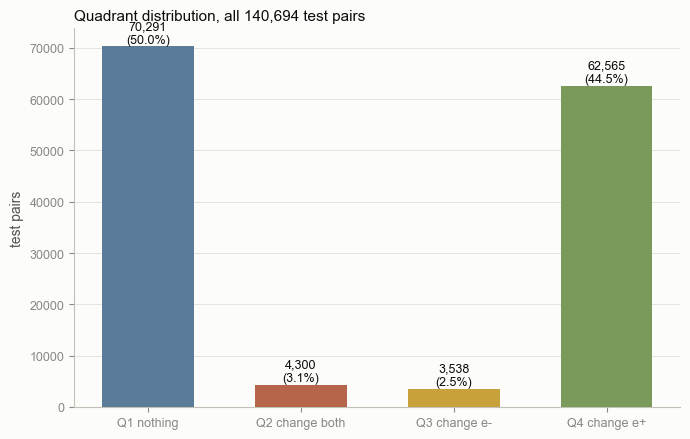

In [10]:
# cell 17
QUAD_ORDER = ["Q1 nothing", "Q2 change both", "Q3 change e-", "Q4 change e+"]
counts = tl_reset["quadrant"].value_counts().reindex(QUAD_ORDER).fillna(0).astype(int)
props = counts / counts.sum()

fig, ax = plt.subplots(figsize=(7, 4.5), facecolor=SURFACE)
ax.set_facecolor(SURFACE)
bars = ax.bar(QUAD_ORDER, counts.values, color=[QUADRANT_COLORS[q] for q in QUAD_ORDER], width=0.6, zorder=3)
for b, c, p in zip(bars, counts.values, props.values):
    ax.text(b.get_x() + b.get_width() / 2, c + counts.max() * 0.01, f"{c:,}\n({p:.1%})", ha="center", fontsize=9, color=INK_PRIMARY)
ax.set_ylabel("test pairs", color=INK_SECONDARY, fontsize=10)
ax.set_title(f"Quadrant distribution, all {len(tl_reset):,} test pairs", color=INK_PRIMARY, fontsize=11, loc="left")
for s in ("top", "right"):
    ax.spines[s].set_visible(False)
for s in ("left", "bottom"):
    ax.spines[s].set_color(BASELINE)
ax.tick_params(colors=INK_MUTED, labelsize=9)
ax.grid(axis="y", color=GRID, linewidth=0.6, zorder=0)
plt.tight_layout()
plt.savefig(out_dir / "deltaE_quadrant_distribution_5k.png", dpi=150, facecolor=SURFACE)
plt.show()

*(cell 18)*

##### Output 2: per-quadrant prediction accuracy

,n_pairs,real_RMSE,hyp_RMSE,delta_RMSE
quadrant,,,,
Q1 nothing,70291,0.6776,0.6086,-0.0690
Q2 change both,4300,1.0147,1.0263,0.0117
Q3 change e-,3538,0.5196,0.4860,-0.0336
Q4 change e+,62565,1.0401,1.0628,0.0227


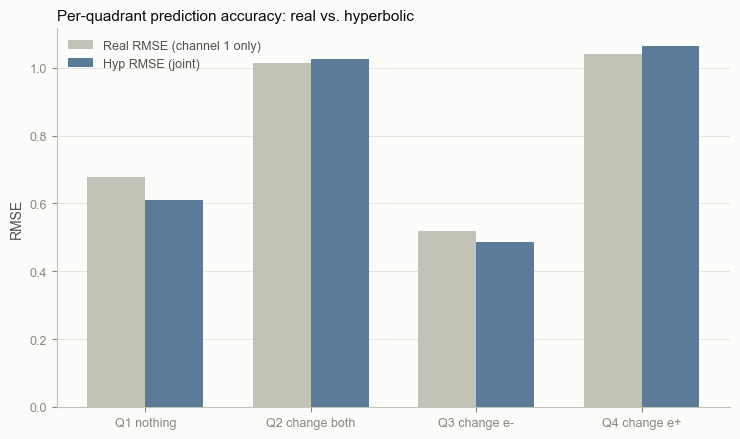

In [11]:
# cell 19
rows = []
for q in QUAD_ORDER:
    sub = tl_reset[tl_reset["quadrant"] == q]
    rmse_real = float(np.sqrt(np.mean((sub["r1_pred"] - sub["rating"]) ** 2)))
    rmse_hyp = float(np.sqrt(np.mean((sub["r_joint_pred"] - sub["rating"]) ** 2)))
    rows.append({"quadrant": q, "n_pairs": len(sub), "real_RMSE": rmse_real, "hyp_RMSE": rmse_hyp, "delta_RMSE": rmse_hyp - rmse_real})

quad_rmse_table = pd.DataFrame(rows).set_index("quadrant")
display(quad_rmse_table.round(4))

fig, ax = plt.subplots(figsize=(7.5, 4.5), facecolor=SURFACE)
ax.set_facecolor(SURFACE)
x = np.arange(len(QUAD_ORDER))
width = 0.35
ax.bar(x - width / 2, quad_rmse_table["real_RMSE"], width, color="#c3c2b7", label="Real RMSE (channel 1 only)", zorder=3)
ax.bar(x + width / 2, quad_rmse_table["hyp_RMSE"], width, color="#5b7c99", label="Hyp RMSE (joint)", zorder=3)
ax.set_xticks(x)
ax.set_xticklabels(QUAD_ORDER, fontsize=9)
ax.set_ylabel("RMSE", color=INK_SECONDARY, fontsize=10)
ax.set_title("Per-quadrant prediction accuracy: real vs. hyperbolic", color=INK_PRIMARY, fontsize=11, loc="left")
ax.legend(loc="best", frameon=False, fontsize=9, labelcolor=INK_SECONDARY)
for s in ("top", "right"):
    ax.spines[s].set_visible(False)
for s in ("left", "bottom"):
    ax.spines[s].set_color(BASELINE)
ax.tick_params(colors=INK_MUTED, labelsize=9)
ax.grid(axis="y", color=GRID, linewidth=0.6, zorder=0)
plt.tight_layout()
plt.savefig(out_dir / "deltaE_quadrant_rmse_5k.png", dpi=150, facecolor=SURFACE)
plt.show()

*(cell 20)*

##### Output 2b: per-quadrant calibration -- letting the quadrant participate in the combination itself

Output 2 above fit one global calibration (`r_joint = r1 + beta0 + beta1*v_recon2`) and only *afterward* checked how it performed per quadrant -- the quadrant never entered the combination step, only the post-hoc analysis. This section fits a **separate** `(beta0, beta1)` per quadrant instead, so the quadrant genuinely participates in producing the final prediction, not just in diagnosing it afterward. This is the direct test of whether $\Delta_1$/$\Delta_2$'s extra visibility (over a single real-valued $\Delta E$) can be turned into better predictions, not just a finer diagnosis.

,n_pairs,beta0,beta1,real_RMSE,perquadrant_hyp_RMSE,delta_RMSE
quadrant,,,,,,
Q1 nothing,70291,0.3327,0.1803,0.6776,0.5614,-0.1163
Q2 change both,4300,-0.1885,1.2711,1.0147,0.9932,-0.0214
Q3 change e-,3538,0.2173,0.4559,0.5196,0.4617,-0.0580
Q4 change e+,62565,-0.1777,0.2659,1.0401,1.0318,-0.0084


overall RMSE:
  real-only:                  0.8653
  global-calibrated hyp:      0.8518
  per-quadrant-calibrated hyp: 0.8163

every quadrant improves over real-only once the quadrant itself
is allowed to shape the combination (compare delta_RMSE above to
Output 2's delta_RMSE, which was positive/worse for Q4)


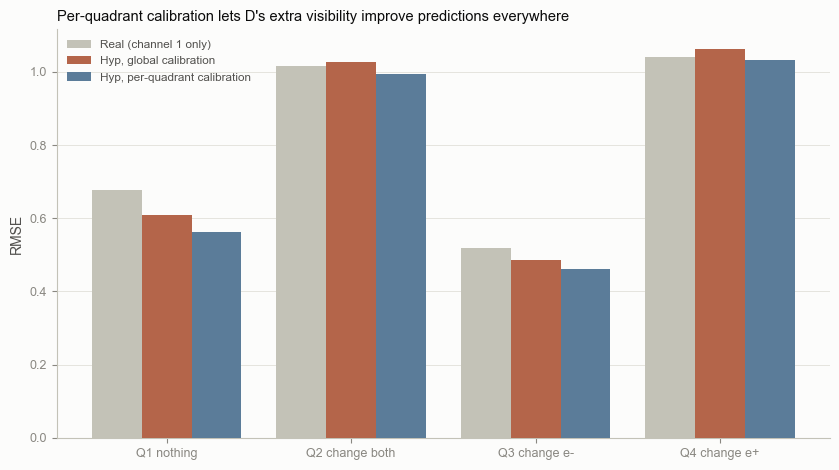

In [12]:
# cell 21
rows_perq = []
r_joint_perq_full = np.empty(len(tl_reset), dtype=np.float64)
for q in QUAD_ORDER:
    mask_q = (tl_reset["quadrant"] == q).values
    sub = tl_reset[mask_q]
    resid_q = sub["rating"].values - sub["r1_pred"].values
    X_q = np.column_stack([np.ones(len(sub)), sub["v_recon2"].values])
    b, *_ = np.linalg.lstsq(X_q, resid_q, rcond=None)
    r_joint_q = np.clip(sub["r1_pred"].values + b[0] + b[1] * sub["v_recon2"].values, 0.5, 5.0)
    r_joint_perq_full[mask_q] = r_joint_q

    rmse_real_q = float(np.sqrt(np.mean((sub["r1_pred"] - sub["rating"]) ** 2)))
    rmse_perq_q = float(np.sqrt(np.mean((r_joint_q - sub["rating"]) ** 2)))
    rows_perq.append({"quadrant": q, "n_pairs": len(sub), "beta0": b[0], "beta1": b[1],
                       "real_RMSE": rmse_real_q, "perquadrant_hyp_RMSE": rmse_perq_q,
                       "delta_RMSE": rmse_perq_q - rmse_real_q})

tl_reset["r_joint_pred_perquadrant"] = r_joint_perq_full
perq_table = pd.DataFrame(rows_perq).set_index("quadrant")
display(perq_table.round(4))

rmse_real_all = float(np.sqrt(np.mean((tl_reset["r1_pred"] - tl_reset["rating"]) ** 2)))
rmse_global_calib_all = float(np.sqrt(np.mean((tl_reset["r_joint_pred"] - tl_reset["rating"]) ** 2)))
rmse_perq_all = float(np.sqrt(np.mean((tl_reset["r_joint_pred_perquadrant"] - tl_reset["rating"]) ** 2)))
print("overall RMSE:")
print(f"  real-only:                  {rmse_real_all:.4f}")
print(f"  global-calibrated hyp:      {rmse_global_calib_all:.4f}")
print(f"  per-quadrant-calibrated hyp: {rmse_perq_all:.4f}")
print()
print("every quadrant improves over real-only once the quadrant itself")
print("is allowed to shape the combination (compare delta_RMSE above to")
print("Output 2's delta_RMSE, which was positive/worse for Q4)")

fig, ax = plt.subplots(figsize=(8.5, 4.8), facecolor=SURFACE)
ax.set_facecolor(SURFACE)
x = np.arange(len(QUAD_ORDER))
width = 0.27
ax.bar(x - width, quad_rmse_table["real_RMSE"], width, color="#c3c2b7", label="Real (channel 1 only)", zorder=3)
ax.bar(x, quad_rmse_table["hyp_RMSE"], width, color="#b4654a", label="Hyp, global calibration", zorder=3)
ax.bar(x + width, perq_table["perquadrant_hyp_RMSE"], width, color="#5b7c99", label="Hyp, per-quadrant calibration", zorder=3)
ax.set_xticks(x)
ax.set_xticklabels(QUAD_ORDER, fontsize=9)
ax.set_ylabel("RMSE", color=INK_SECONDARY, fontsize=10)
ax.set_title("Per-quadrant calibration lets D's extra visibility improve predictions everywhere", color=INK_PRIMARY, fontsize=10.5, loc="left")
ax.legend(loc="best", frameon=False, fontsize=8.5, labelcolor=INK_SECONDARY)
for s in ("top", "right"):
    ax.spines[s].set_visible(False)
for s in ("left", "bottom"):
    ax.spines[s].set_color(BASELINE)
ax.tick_params(colors=INK_MUTED, labelsize=9)
ax.grid(axis="y", color=GRID, linewidth=0.6, zorder=0)
plt.tight_layout()
plt.savefig(out_dir / "deltaE_quadrant_rmse_perquadrant_calib_5k.png", dpi=150, facecolor=SURFACE)
plt.show()

*(cell 22)*

##### Output 3: $\Delta_1$ vs $\Delta_2$ scatter (sampled), R vs D decision boundaries

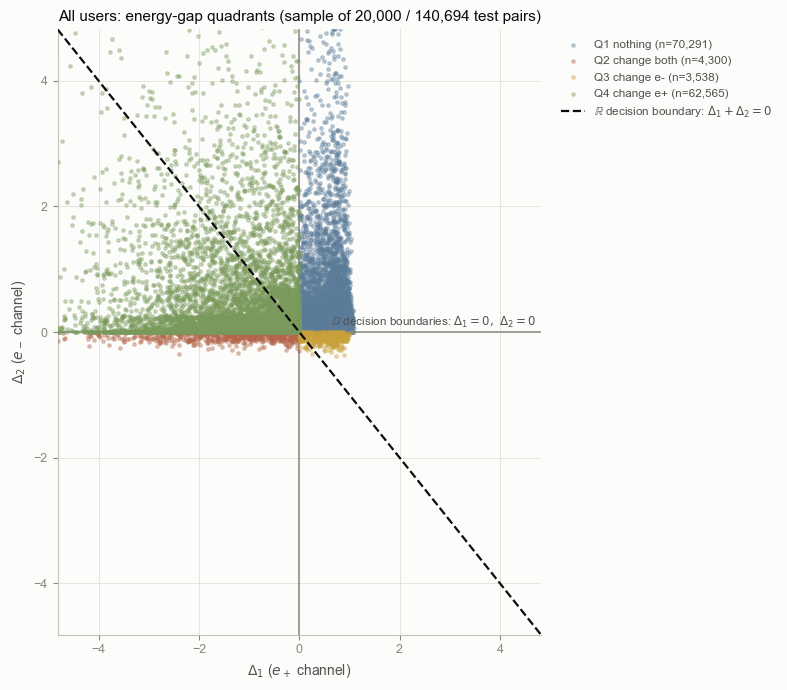

In [13]:
# cell 23
rng = np.random.default_rng(0)
sample_idx = rng.choice(len(tl_reset), size=min(20000, len(tl_reset)), replace=False)
sample = tl_reset.iloc[sample_idx]

fig, ax = plt.subplots(figsize=(8, 7), facecolor=SURFACE)
ax.set_facecolor(SURFACE)
for q, color in QUADRANT_COLORS.items():
    sub = sample[sample["quadrant"] == q]
    ax.scatter(sub["Delta1"], sub["Delta2"], color=color, s=6, alpha=0.35, zorder=3, label=f"{q} (n={(tl_reset['quadrant'] == q).sum():,})")

lim = np.percentile(np.abs(np.concatenate([sample["Delta1"].values, sample["Delta2"].values])), 99.5)
ax.plot([-lim, lim], [lim, -lim], color=INK_PRIMARY, linewidth=1.6, linestyle="--", zorder=4, label=r"$\mathbb{R}$ decision boundary: $\Delta_1+\Delta_2=0$")
ax.axhline(0, color=INK_MUTED, linewidth=1.1, zorder=2)
ax.axvline(0, color=INK_MUTED, linewidth=1.1, zorder=2)
ax.text(lim * 0.98, 0.02 * lim, r"$\mathbb{D}$ decision boundaries: $\Delta_1=0,\ \Delta_2=0$", ha="right", fontsize=8.5, color=INK_SECONDARY)
ax.set_xlim(-lim, lim)
ax.set_ylim(-lim, lim)
ax.set_xlabel(r"$\Delta_1$ ($e_+$ channel)", color=INK_SECONDARY, fontsize=10)
ax.set_ylabel(r"$\Delta_2$ ($e_-$ channel)", color=INK_SECONDARY, fontsize=10)
ax.set_title(f"All users: energy-gap quadrants (sample of {len(sample):,} / {len(tl_reset):,} test pairs)", color=INK_PRIMARY, fontsize=11, loc="left")
ax.legend(loc="upper left", bbox_to_anchor=(1.02, 1.0), frameon=False, fontsize=8.5, labelcolor=INK_SECONDARY)
for s in ("top", "right"):
    ax.spines[s].set_visible(False)
for s in ("left", "bottom"):
    ax.spines[s].set_color(BASELINE)
ax.tick_params(colors=INK_MUTED, labelsize=9)
ax.grid(color=GRID, linewidth=0.6, zorder=0)
plt.tight_layout()
plt.savefig(out_dir / "deltaE_quadrant_scatter_5k.png", dpi=150, facecolor=SURFACE, bbox_inches="tight")
plt.show()

*(cell 24)*

##### Output 4: real vs. D verdict, side by side, for concrete example pairs

Two real test pairs per quadrant, pulled directly from the data above -- not hand-picked. Real number's verdict comes from sign(Delta1+Delta2) only (two possible verdicts); D's verdict reads Delta1 and Delta2 separately (names which channel, if any, needs changing).

In [14]:
# cell 25
col_to_movie = {j: int(mid) for mid, j in movie_to_col.items()}
movies_title_map = pd.read_csv(root / "data" / "movie.csv").set_index("movieId")["title"].to_dict()

def real_verdict(d1, d2):
    return "nothing" if (d1 + d2) > 0 else "change both"

def d_verdict(d1, d2):
    if d1 > 0 and d2 > 0:
        return "nothing"
    if d1 < 0 and d2 < 0:
        return "change both"
    if d1 > 0 and d2 < 0:
        return "change e- only"
    return "change e+ only"

example_rows = []
for q in QUAD_ORDER:
    sub = tl_reset[tl_reset["quadrant"] == q].head(2)
    for _, r in sub.iterrows():
        title = movies_title_map.get(col_to_movie[r["movie_col"]], "?")
        example_rows.append({
            "quadrant": q,
            "movie": title[:35],
            "rating": r["rating"],
            "Delta1": r["Delta1"],
            "Delta2": r["Delta2"],
            "Delta1+Delta2": r["Delta1"] + r["Delta2"],
            "real verdict": real_verdict(r["Delta1"], r["Delta2"]),
            "D verdict": d_verdict(r["Delta1"], r["Delta2"]),
        })
        example_rows[-1]["real misjudged?"] = "<-- YES" if example_rows[-1]["real verdict"] != example_rows[-1]["D verdict"] else ""

example_table = pd.DataFrame(example_rows).set_index(["quadrant", "movie"])
display(example_table.round(4))

rating  Delta1  Delta2  \
quadrant       movie                                                         
Q1 nothing     Man of the Year (1995)                  3.0  0.2048  0.2403   
               League of Ordinary Gentlemen, A (20     2.5  0.4710  0.2393   
Q2 change both Manchurian Candidate, The (2004)        3.0 -0.4138 -0.0082   
               Labyrinth (1986)                        3.5 -1.6467 -0.0177   
Q3 change e-   Pitch Black (2000)                      3.0  0.0657 -0.0178   
               Thank You for Smoking (2006)            4.0  0.0950 -0.0106   
Q4 change e+   Mighty, The (1998)                      3.5 -2.1305  0.0795   
               Everest (1998)                          3.5 -2.5064  0.0396   

                                                    Delta1+Delta2  \
quadrant       movie                                                
Q1 nothing     Man of the Year (1995)                      0.4451   
               League of Ordinary Gentlemen, A (20         0.7103   
Q2 change both Manchurian Candidate, The (2004)           -0.4221   
               Labyrinth (1986)                           -1.6644   
Q3 change e-   Pitch Black (2000)                          0.0479   
               Thank You for Smoking (2006)                0.0844   
Q4 change e+   Mighty, The (1998)                         -2.0509   
               Everest (1998)                             -2.4668   

                                                   real verdict  \
quadrant       movie                                              
Q1 nothing     Man of the Year (1995)                   nothing   
               League of Ordinary Gentlemen, A (20      nothing   
Q2 change both Manchurian Candidate, The (2004)     change both   
               Labyrinth (1986)                     change both   
Q3 change e-   Pitch Black (2000)                       nothing   
               Thank You for Smoking (2006)             nothing   
Q4 change e+   Mighty, The (1998)                   change both   
               Everest (1998)                       change both   

                                                         D verdict  \
quadrant       movie                                                 
Q1 nothing     Man of the Year (1995)                      nothing   
               League of Ordinary Gentlemen, A (20         nothing   
Q2 change both Manchurian Candidate, The (2004)        change both   
               Labyrinth (1986)                        change both   
Q3 change e-   Pitch Black (2000)                   change e- only   
               Thank You for Smoking (2006)         change e- only   
Q4 change e+   Mighty, The (1998)                   change e+ only   
               Everest (1998)                       change e+ only   

                                                   real misjudged?  
quadrant       movie                                                
Q1 nothing     Man of the Year (1995)                               
               League of Ordinary Gentlemen, A (20                  
Q2 change both Manchurian Candidate, The (2004)                     
               Labyrinth (1986)                                     
Q3 change e-   Pitch Black (2000)                          <-- YES  
               Thank You for Smoking (2006)                <-- YES  
Q4 change e+   Mighty, The (1998)                          <-- YES  
               Everest (1998)                              <-- YES

*(cell 26)*

##### Output 5: summary

In [15]:
# cell 27
n_total = len(tl_reset)
n_single_channel = int((tl_reset["quadrant"].isin(["Q3 change e-", "Q4 change e+"])).sum())
prop_single_channel = n_single_channel / n_total

sub_single = tl_reset[tl_reset["quadrant"].isin(["Q3 change e-", "Q4 change e+"])]
rmse_real_single = float(np.sqrt(np.mean((sub_single["r1_pred"] - sub_single["rating"]) ** 2)))
rmse_hyp_single = float(np.sqrt(np.mean((sub_single["r_joint_pred"] - sub_single["rating"]) ** 2)))

print(f"total test pairs: {n_total:,}")
print(f"single-channel-wrong pairs (Q3+Q4): {n_single_channel:,}  ({prop_single_channel:.2%} of all test pairs)")
print("  -- this fraction is entirely invisible to a real-valued RBM, which only sees sign(Delta1+Delta2)")
print()
print(f"within Q3+Q4 only: real RMSE={rmse_real_single:.4f}  hyp RMSE={rmse_hyp_single:.4f}  gap={rmse_hyp_single - rmse_real_single:+.4f}")
print("  -- this gap is the marginal accuracy contribution of the D-valued joint prediction, isolated to exactly the pairs where R's single scalar view cannot distinguish which channel needs correcting")


total test pairs: 140,694
single-channel-wrong pairs (Q3+Q4): 66,103  (46.98% of all test pairs)
  -- this fraction is entirely invisible to a real-valued RBM, which only sees sign(Delta1+Delta2)

within Q3+Q4 only: real RMSE=1.0190  hyp RMSE=1.0401  gap=+0.0211
  -- this gap is the marginal accuracy contribution of the D-valued joint prediction, isolated to exactly the pairs where R's single scalar view cannot distinguish which channel needs correcting
